In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

user_features = pd.read_csv('../data/processed/user_features.csv')
print(f"Loaded: {user_features.shape}")

Loaded: (962037, 19)


In [2]:
cluster_cols = [
    'total_plays', 'unique_tracks', 'unique_artists',
    'repeat_rate', 'artist_loyalty', 'genre_diversity',
    'avg_danceability', 'avg_energy', 'avg_valence',
    'avg_acousticness', 'avg_instrumentalness',
    'avg_tempo', 'avg_loudness', 'avg_track_year'
]

X = user_features[cluster_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix: {X_scaled.shape}")

Feature matrix: (962037, 14)


k=2  inertia=11526036  silhouette=0.219
k=3  inertia=10119919  silhouette=0.170
k=4  inertia=9292032  silhouette=0.135
k=5  inertia=8613324  silhouette=0.123
k=6  inertia=8291064  silhouette=0.126
k=7  inertia=7982663  silhouette=0.108
k=8  inertia=7700780  silhouette=0.105


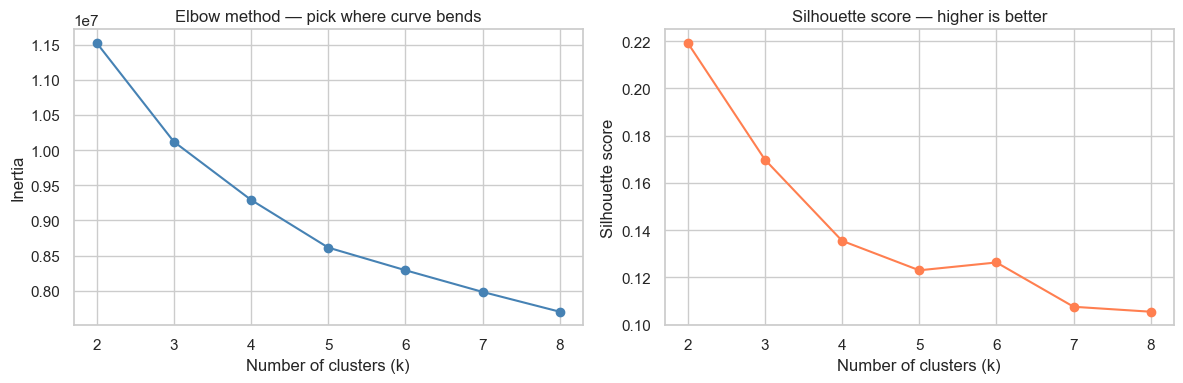

In [3]:
inertia    = []
silhouette = []
k_range    = range(2, 9)

# sample for silhouette — keeps memory usage low on 962K users
SAMPLE_SIZE = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample   = X_scaled[sample_idx]

for k in k_range:
    # MiniBatchKMeans — much faster than KMeans on large datasets
    km = MiniBatchKMeans(n_clusters=k, random_state=42,
                          batch_size=2048, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

    sample_labels = km.predict(X_sample)
    sil = silhouette_score(X_sample, sample_labels)
    silhouette.append(sil)
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertia, 'o-', color='steelblue')
axes[0].set_title('Elbow method — pick where curve bends')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette, 'o-', color='coral')
axes[1].set_title('Silhouette score — higher is better')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.savefig('../data/processed/plot_cluster_selection.png', dpi=120)
plt.show()

In [4]:
# Set BEST_K based on Cell 3's elbow + silhouette plots
BEST_K = 4

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
user_features['cluster'] = km_final.fit_predict(X_scaled)

print(f"Cluster distribution:")
print(user_features['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    171422
1    248907
2    408553
3    133155
Name: count, dtype: int64


PC1 explains 24.8%
PC2 explains 19.3%
Total        44.1%


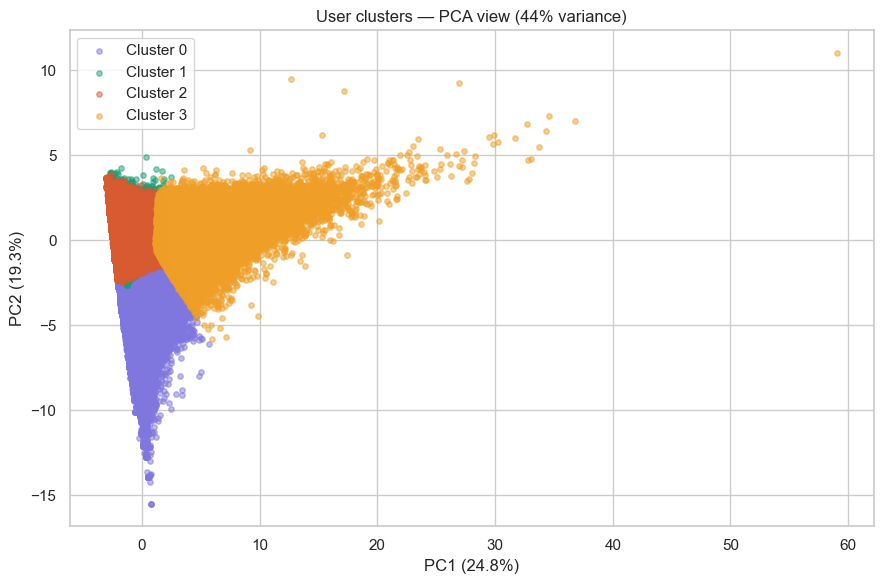

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained[0]:.1f}%")
print(f"PC2 explains {explained[1]:.1f}%")
print(f"Total        {sum(explained):.1f}%")

colors = ['#7F77DD', '#1D9E75', '#D85A30', '#EF9F27', '#D4537E', '#378ADD']

plt.figure(figsize=(9, 6))
for c in range(BEST_K):
    mask = user_features['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {c}',
                color=colors[c], alpha=0.5, s=15)

plt.title(f'User clusters — PCA view ({sum(explained):.0f}% variance)')
plt.xlabel(f'PC1 ({explained[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained[1]:.1f}%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot_clusters_pca.png', dpi=120)
plt.show()

PC1 explains 24.8%
PC2 explains 19.3%
Total        44.1%


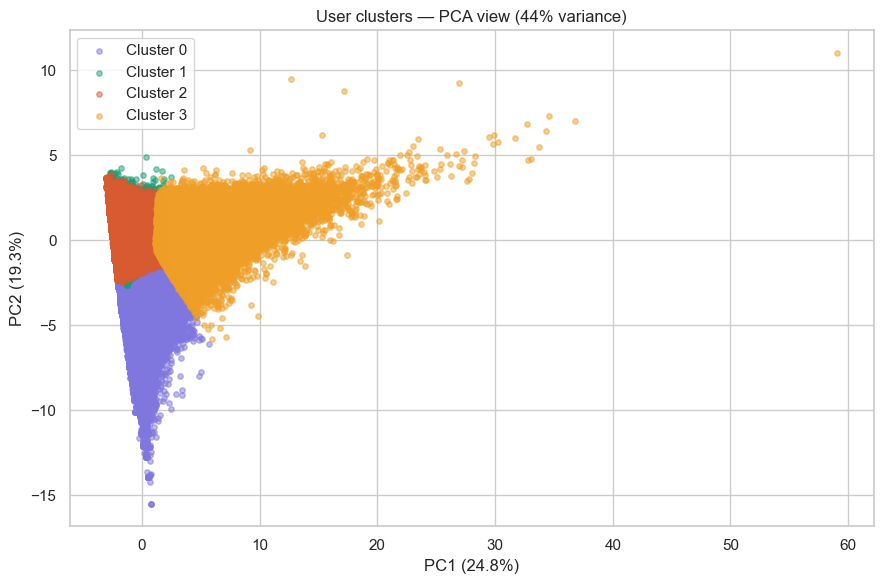

In [6]:
# Cell 5 — Visualise clusters in 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained[0]:.1f}%")
print(f"PC2 explains {explained[1]:.1f}%")
print(f"Total        {sum(explained):.1f}%")

colors = ['#7F77DD', '#1D9E75', '#D85A30', '#EF9F27', '#D4537E', '#378ADD']

plt.figure(figsize=(9, 6))
for c in range(BEST_K):
    mask = user_features['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {c}',
                color=colors[c], alpha=0.5, s=15)

plt.title(f'User clusters — PCA view ({sum(explained):.0f}% variance)')
plt.xlabel(f'PC1 ({explained[0]:.1f}%)')
plt.ylabel(f'PC2 ({explained[1]:.1f}%)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/plot_clusters_pca.png', dpi=120)
plt.show()

In [7]:
# Cell 6 — Profile each cluster
profile = user_features.groupby('cluster')[cluster_cols].mean().T
print("=== Cluster Profiles (mean values) ===")
print(profile.round(2))

=== Cluster Profiles (mean values) ===
cluster                     0        1        2        3
total_plays             15.44    15.09    16.72    92.51
unique_tracks            6.18     5.04     6.42    35.86
unique_artists           4.04     3.55     5.10    21.51
repeat_rate              2.77     3.39     2.79     3.17
artist_loyalty           0.60     0.64     0.50     0.25
genre_diversity          1.64     1.39     1.91     4.26
avg_danceability         0.50     0.46     0.61     0.53
avg_energy               0.49     0.80     0.70     0.68
avg_valence              0.38     0.41     0.57     0.46
avg_acousticness         0.45     0.09     0.18     0.22
avg_instrumentalness     0.23     0.13     0.09     0.17
avg_tempo              116.57   133.83   119.65   123.44
avg_loudness           -10.90    -6.21    -7.13    -7.85
avg_track_year        2003.88  2005.13  2005.31  2004.83


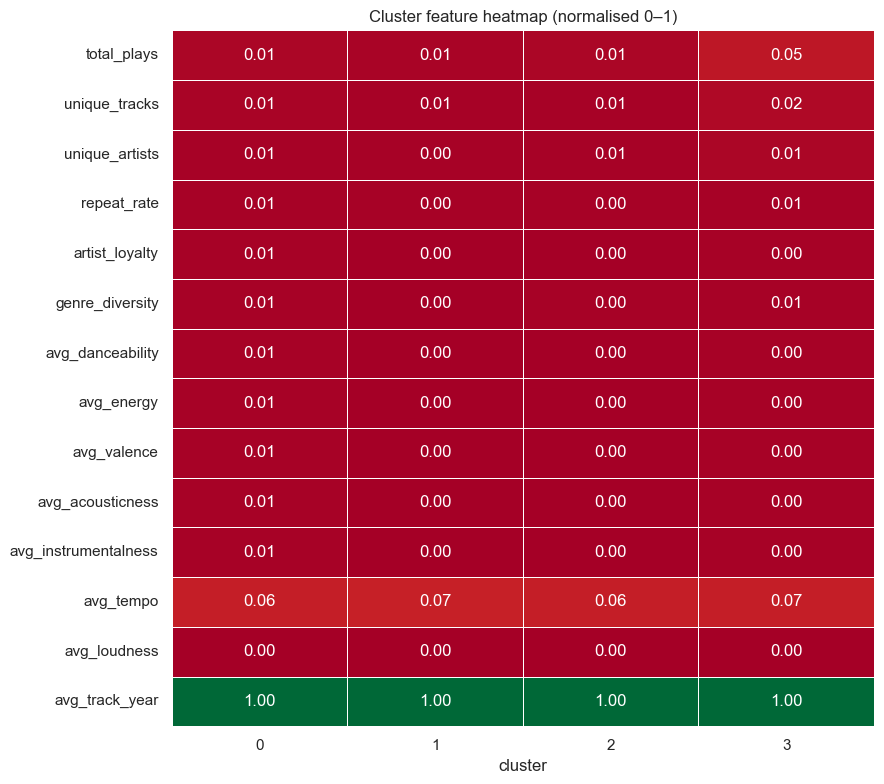

In [8]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

plt.figure(figsize=(9, 8))
sns.heatmap(profile_norm, annot=True, fmt='.2f',
            cmap='RdYlGn', linewidths=0.5, cbar=False)
plt.title('Cluster feature heatmap (normalised 0–1)')
plt.tight_layout()
plt.savefig('../data/processed/plot_cluster_heatmap.png', dpi=120)
plt.show()

In [9]:
# Fill these in AFTER reviewing Cell 6 / Cell 7 output
cluster_names = {
    0: 'Energetic Pop Fans',
    1: 'Chill Acoustic Listeners',
    2: 'Loyal Superfans',
    3: 'Casual Explorers',
}

user_features['segment'] = user_features['cluster'].map(cluster_names)

print("Segment distribution:")
print(user_features['segment'].value_counts())

user_features.to_csv('../data/processed/user_features.csv', index=False)
print("\nSaved with cluster labels ✓")

Segment distribution:
segment
Loyal Superfans             408553
Chill Acoustic Listeners    248907
Energetic Pop Fans          171422
Casual Explorers            133155
Name: count, dtype: int64

Saved with cluster labels ✓
